# Data Science & AI/ML Practical Exam —  Set A : Predict campaign responses and identify audience segments. 


In [50]:
from pathlib import Path
import sys
import platform
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, silhouette_score
)
import json
SEED = 42
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

import joblib
import torch
import torch.nn as nn

In [51]:
ROOT = Path("..")
RAW_CSV = ROOT / "data" / "raw" / "set_a.csv"
OUT = ROOT / "outputs"
FIG = OUT / "figures"
MODELS = ROOT / "models"
for p in (OUT, FIG, MODELS):
    p.mkdir(parents=True, exist_ok=True)

import sklearn, scipy, tensorflow as tf
print("numpy       :", np.__version__)
print("pandas      :", pd.__version__)
print("scipy       :", scipy.__version__)
print("scikit-learn:", sklearn.__version__)
print("tensorflow  :", tf.__version__)

tf.random.set_seed(RANDOM_STATE)

numpy       : 2.3.5
pandas      : 2.3.3
scipy       : 1.16.3
scikit-learn: 1.9.0
tensorflow  : 2.21.0


## Data setup

In [52]:
from pathlib import Path

rng = np.random.default_rng(404)
n = 300
cols = ['visits', 'recency', 'engagement', 'spend']
x = rng.normal(size=(n, 4))
group = rng.choice(["G1", "G2"], size=n)
score = x @ np.array([0.6, -0.9, 1.1, 0.4])
score += 0.4 * (group == "G2") + rng.normal(0, 1, n)
y = (score > 0).astype(int)
df = pd.DataFrame(np.round(50 + 10*x, 2), columns=cols)
df.insert(0, "record_id", np.arange(1, n+1))
df["group"] = group
df["response"] = y
for col in cols[:2]:
    df.loc[rng.choice(n, 15, replace=False), col] = np.nan
df = pd.concat([df, df.iloc[:5]], ignore_index=True)
Path("data/raw").mkdir(parents=True, exist_ok=True)
df.to_csv("data/raw/set_a.csv", index=False)


In [53]:
df_raw = pd.read_csv("data/raw/set_a.csv")

In [54]:
df_raw

,record_id,visits,recency,engagement,spend,group,response
0,1,53.96,43.84,54.57,58.93,G2,1
1,2,NaN,49.75,52.97,63.64,G2,1
2,3,35.39,66.52,44.98,47.33,G2,0
3,4,45.01,42.80,47.62,54.48,G1,1
4,5,53.84,53.72,48.33,58.30,G2,1
...,...,...,...,...,...,...,...
300,1,53.96,43.84,54.57,58.93,G2,1
301,2,NaN,49.75,52.97,63.64,G2,1
302,3,35.39,66.52,44.98,47.33,G2,0
303,4,45.01,42.80,47.62,54.48,G1,1


In [55]:
print("describe:", df_raw.describe(include="all").T)
print("Raw shape:", df_raw.shape)
print("info:", df_raw.info())

describe:             count unique  top freq        mean        std    min      25%  \
record_id   305.0    NaN  NaN  NaN  148.081967  88.052447    1.0     72.0   
visits      289.0    NaN  NaN  NaN   49.293599   9.846792  20.32    42.62   
recency     290.0    NaN  NaN  NaN   49.950724   9.687006   18.9  43.4375   
engagement  305.0    NaN  NaN  NaN   50.903213   10.47972  23.13    43.89   
spend       305.0    NaN  NaN  NaN   49.922984  10.134986   5.07    42.93   
group         305      2   G2  162         NaN        NaN    NaN      NaN   
response    305.0    NaN  NaN  NaN    0.580328   0.494316    0.0      0.0   

               50%      75%    max  
record_id    148.0    224.0  300.0  
visits        49.4    55.95  75.81  
recency     49.695  55.9025  81.17  
engagement   51.24    57.26  81.99  
spend        50.28     57.2  79.71  
group          NaN      NaN    NaN  
response       1.0      1.0    1.0  
Raw shape: (305, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 305 ent

In [56]:
n_exact_dupes = df_raw.duplicated(keep="first").sum()
print("Exact duplicate rows:", n_exact_dupes)

missing_counts = df_raw.isna().sum()
print("\nMissing value counts per column:")
print(missing_counts)

print("\nTarget response counts (raw, incl. duplicates):")
print(df_raw["response"].value_counts())

Exact duplicate rows: 5

Missing value counts per column:
record_id      0
visits        16
recency       15
engagement     0
spend          0
group          0
response       0
dtype: int64

Target response counts (raw, incl. duplicates):
response
1    177
0    128
Name: count, dtype: int64


In [57]:
df = df_raw.drop_duplicates(keep="first").reset_index(drop=True)
print("\nShape after removing exact duplicates:", df.shape)
assert df.shape[0] == 300, "Expected exactly 300 unique records after cleaning"
assert df["record_id"].is_unique, "record_id must be unique after de-duplication"
print("Verified: 300 unique records, record_id is unique.")


Shape after removing exact duplicates: (300, 7)
Verified: 300 unique records, record_id is unique.


In [58]:
from sklearn.model_selection import train_test_split as tts
fit_df, tmp = tts(df, test_size=108, stratify=df["response"], random_state=RANDOM_STATE)
val_df, test_df = tts(tmp, test_size=60, stratify=tmp["response"], random_state=RANDOM_STATE)

print("fit :", fit_df.shape[0], "records")
print("val :", val_df.shape[0], "records")
print("test:", test_df.shape[0], "records")

fit : 192 records
val : 48 records
test: 60 records


In [59]:
assert (fit_df.shape[0], val_df.shape[0], test_df.shape[0]) == (192, 48, 60), \
    "Partition sizes must be exactly 192 / 48 / 60"

fit_ids, val_ids, test_ids = set(fit_df.record_id), set(val_df.record_id), set(test_df.record_id)
assert fit_ids.isdisjoint(val_ids)
assert fit_ids.isdisjoint(test_ids)
assert val_ids.isdisjoint(test_ids)
print("Verified: fit / validation / test record_id sets are pairwise disjoint.")

splits = pd.concat([
    fit_df.assign(partition="fit"),
    val_df.assign(partition="validation"),
    test_df.assign(partition="test"),
])[["record_id", "partition"]].sort_values("record_id").reset_index(drop=True)
splits.to_csv(OUT / "splits.csv", index=False)
splits.head()

Verified: fit / validation / test record_id sets are pairwise disjoint.


,record_id,partition
0,1,test
1,2,fit
2,3,fit
3,4,validation
4,5,fit


# Task 1 — Maths & Adv Stats (5 Marks)
## M1 — Descriptive Statistics

In [60]:
visits = fit_df["visits"].dropna()

summary = pd.DataFrame({
    "observed_n": [visits.size],
    "mean": [visits.mean()],
    "median": [visits.median()],
    "sample_std_ddof1": [visits.std(ddof=1)]
}, index=["visits"])

summary.to_csv("statistics_summary.csv")
summary

,observed_n,mean,median,sample_std_ddof1
visits,184,50.021304,49.66,10.227501


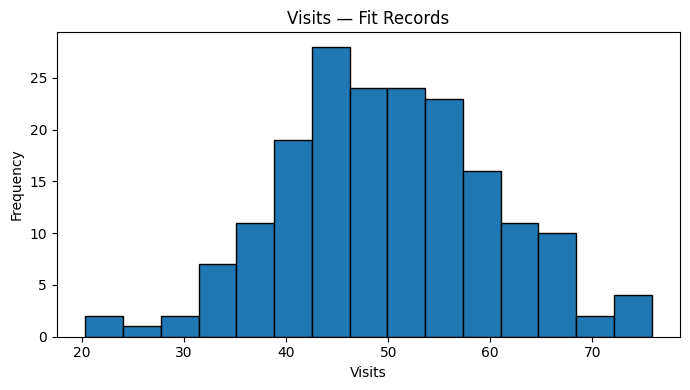

In [61]:
plt.figure(figsize=(7, 4))
plt.hist(visits, bins=15, edgecolor="black")
plt.title("Visits — Fit Records")
plt.xlabel("Visits")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("visits_histogram.png", dpi=150)
plt.show()

## M2 — Statistical Inference

In [62]:
g1 = fit_df.loc[fit_df["group"] == "G1", "visits"].dropna()
g2 = fit_df.loc[fit_df["group"] == "G2", "visits"].dropna()

t_stat, p_value = stats.ttest_ind(g1, g2, equal_var=False, alternative="two-sided")

mean_temp = visits.mean()
sem = stats.sem(visits)
ci_low, ci_high = stats.t.interval(
    confidence=0.95,
    df=len(visits) - 1,
    loc=mean_temp,
    scale=sem
)

inference = pd.DataFrame({
    "G1_n": [len(g1)],
    "G2_n": [len(g2)],
    "t_statistic": [t_stat],
    "p_value": [p_value],
    "overall_observed_n": [len(visits)],
    "mean_visits": [visits.mean()],
    "ci95_low": [ci_low],
    "ci95_high": [ci_high],
    "alpha": [0.05]
})
inference.to_csv("inference_results.csv", index=False)
inference

,G1_n,G2_n,t_statistic,p_value,overall_observed_n,mean_visits,ci95_low,ci95_high,alpha
0,81,103,-0.247834,0.804567,184,50.021304,48.53369,51.508919,0.05


In [63]:
print(f"Welch t-test p-value: {p_value:.4f}")

if p_value < 0.05:
    print("At alpha=0.05, the observed group means are statistically different.")
else:
    print("At alpha=0.05, there is not enough evidence of a difference in group means.")
print(f"95% CI for overall observed mean visits: ({ci_low:.2f}, {ci_high:.2f})")

Welch t-test p-value: 0.8046
At alpha=0.05, there is not enough evidence of a difference in group means.
95% CI for overall observed mean visits: (48.53, 51.51)


## M3 — Linear Algebra

In [64]:
complete_tv = fit_df[["visits", "engagement"]].dropna().to_numpy()
X_centered = complete_tv - complete_tv.mean(axis=0)
cov_matrix = X_centered.T @ X_centered / (len(X_centered) - 1)

eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
order = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

variance_share = eigenvalues[0] / eigenvalues.sum()
principal_direction = eigenvectors[:, 0]

cov_df = pd.DataFrame(cov_matrix, index=["visits", "engagement"], columns=["visits", "engagement"])
print("Complete rows:", len(complete_tv))
print("Sample covariance matrix:")
print(cov_df)
print("Eigenvalues:", eigenvalues)
print(f"Largest eigenvalue / total = {variance_share:.4f}")
print("Principal direction [visits, engagement]:", principal_direction)

cov_df.to_csv("covariance_matrix.csv")
pd.DataFrame({"eigenvalue": eigenvalues, "variance_share": eigenvalues / eigenvalues.sum()}).to_csv("eigenvalues.csv", index=False)

Complete rows: 184
Sample covariance matrix:
                visits  engagement
visits      104.601782    0.816822
engagement    0.816822  103.212904
Eigenvalues: [104.97946421 102.83522141]
Largest eigenvalue / total = 0.5052
Principal direction [visits, engagement]: [-0.90766853 -0.4196878 ]


# Task 2 — Data Preprocessing & Feature Engineering (5 Marks)

## F1 — Audit and Partition

In [65]:
audit = {
    "raw_shape": list(df_raw.shape),
    "exact_duplicates_removed": int(n_exact_dupes),
    "clean_unique_records": int(df.shape[0]),
    "missing_counts_raw": missing_counts.to_dict(),
    "target_counts_clean": df["response"].value_counts().to_dict(),
    "partition_sizes": {"fit": len(fit_df), "validation": len(val_df), "test": len(test_df)},
    "partitions_disjoint": True,
}


### Save the audit summary in json


In [66]:
with open(OUT / "audit_summary.json", "w") as f:
    json.dump(audit, f, indent=2, default=int)
audit

{'raw_shape': [305, 7],
 'exact_duplicates_removed': 5,
 'clean_unique_records': 300,
 'missing_counts_raw': {'record_id': 0,
  'visits': 16,
  'recency': 15,
  'engagement': 0,
  'spend': 0,
  'group': 0,
  'response': 0},
 'target_counts_clean': {1: 173, 0: 127},
 'partition_sizes': {'fit': 192, 'validation': 48, 'test': 60},
 'partitions_disjoint': True}

## F2 — Transform and Engineer 


In [67]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num = ["visits","recency","engagement","spend"]

for df in [fit_df,val_df,test_df]:
    df["engineered_feature"] = df["engagement"]/(df["recency"]+1)

num += ["engineered_feature"]

pre = ColumnTransformer([
    ("num",Pipeline([("imp",SimpleImputer(strategy="median")),
                     ("sc",StandardScaler())]),num),
    ("cat",OneHotEncoder(handle_unknown="ignore",sparse_output=False),["group"])
])

X_fit = pre.fit_transform(fit_df)
X_val = pre.transform(val_df)
X_test = pre.transform(test_df)

In [68]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import pandas as pd

num = ["visits","recency","engagement","spend"]

imp = SimpleImputer(strategy="median").fit(fit_df[num])

def prep(df):
    x = pd.DataFrame(imp.transform(df[num]), columns=num, index=df.index)
    x["engineered_feature"] = x["engagement"] / (x["recency"] + 1)
    return x

fit_num, val_num, test_num = map(prep, [fit_df, val_df, test_df])


In [69]:
features = num + ["engineered_feature"]
scaler = StandardScaler().fit(fit_num[features])

fit_num[features] = scaler.transform(fit_num[features])
val_num[features] = scaler.transform(val_num[features])
test_num[features] = scaler.transform(test_num[features])

In [70]:
enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False).fit(fit_df[["group"]])

def cat(df):
    return pd.DataFrame(
        enc.transform(df[["group"]]),
        columns=enc.get_feature_names_out(["group"]),
        index=df.index
    )

fit_cat, val_cat, test_cat = map(cat, [fit_df, val_df, test_df])

In [71]:
X_fit = pd.concat([fit_num, fit_cat], axis=1)
X_val = pd.concat([val_num, val_cat], axis=1)
X_test = pd.concat([test_num, test_cat], axis=1)


print(X_fit.shape, X_val.shape, X_test.shape)

(192, 7) (48, 7) (60, 7)


## F3 — Leakage Evidence

In [72]:
print("Fit:", X_fit.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("Features:", X_fit.columns.tolist())

print("Finite:", np.isfinite(X_fit.select_dtypes("number")).all().all())

print("""
Target, record_id, and test statistics are excluded from training
to prevent data leakage. Preprocessing is fitted only on fit data
and then reused unchanged on validation/test data.
""")


Fit: (192, 7)
Validation: (48, 7)
Test: (60, 7)
Features: ['visits', 'recency', 'engagement', 'spend', 'engineered_feature', 'group_G1', 'group_G2']
Finite: True

Target, record_id, and test statistics are excluded from training
to prevent data leakage. Preprocessing is fitted only on fit data
and then reused unchanged on validation/test data.



# Task 3 — Supervised Learning 

## S1 — Baseline and Classifier

In [73]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

y_fit = fit_df["response"]
y_val = val_df["response"]
y_test = test_df["response"]

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_fit, y_fit)

logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_fit, y_fit)

print("Target: default (1 = default, 0 = no default)")
print("Fit IDs:", len(fit_df), "| Validation IDs:", len(val_df), "| Test IDs:", len(test_df))

Target: default (1 = default, 0 = no default)
Fit IDs: 192 | Validation IDs: 48 | Test IDs: 60


In [74]:
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(strategy="most_frequent")

dummy.fit(X_fit, y_fit)

logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logreg.fit(X_fit, y_fit)

print("Target: defect (1 = defect, 0 = no defect)")
print("Predictors:", X_fit.columns.tolist())
print("Logistic Regression settings: max_iter=1000, random_state=42")
print("Fit IDs:", len(fit_df), "| Validation IDs:", len(val_df), "| Test IDs:", len(test_df))

Target: defect (1 = defect, 0 = no defect)
Predictors: ['visits', 'recency', 'engagement', 'spend', 'engineered_feature', 'group_G1', 'group_G2']
Logistic Regression settings: max_iter=1000, random_state=42
Fit IDs: 192 | Validation IDs: 48 | Test IDs: 60


## S2 — Holdout Evaluation 

In [75]:
dummy_pred = dummy.predict(X_test)
log_pred = logreg.predict(X_test)
log_prob = logreg.predict_proba(X_test)[:, 1]

def metric_row(name, y_true, y_pred):
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0)
    }

supervised_metrics = pd.DataFrame([
    metric_row("DummyClassifier", y_test, dummy_pred),
    metric_row("LogisticRegression", y_test, log_pred)
])
supervised_metrics.to_csv("supervised_metrics.csv", index=False)
supervised_metrics

,model,accuracy,precision,recall,f1
0,DummyClassifier,0.566667,0.566667,1.000000,0.723404
1,LogisticRegression,0.816667,0.828571,0.852941,0.840580


## S3 — Interpretation

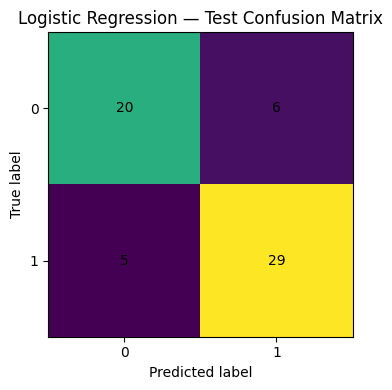

,record_id,true_label,predicted_label,class_1_probability
297,298,1,1,0.924859
136,137,0,0,0.139762
67,68,1,0,0.238225
70,71,0,0,0.322702
7,8,0,1,0.996855


In [76]:
cm = confusion_matrix(y_test, log_pred, labels=[0, 1])
plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Logistic Regression — Test Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks([0, 1], [0, 1])
plt.yticks([0, 1], [0, 1])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.tight_layout()
plt.savefig("logistic_confusion_matrix.png", dpi=150)
plt.show()

predictions = pd.DataFrame({
    "record_id": test_df["record_id"].to_numpy(),
    "true_label": y_test,
    "predicted_label": log_pred,
    "class_1_probability": log_prob
})
predictions.to_csv("logistic_test_predictions.csv", index=False)
predictions.head()

In [77]:
base_f1 = supervised_metrics.loc[supervised_metrics.model == "DummyClassifier", "f1"].iloc[0]
log_f1 = supervised_metrics.loc[supervised_metrics.model == "LogisticRegression", "f1"].iloc[0]
print(f"Dummy F1: {base_f1:.3f}")
print(f"Logistic Regression F1: {log_f1:.3f}")
print("Interpretation: compare the classifier with the majority baseline using the same untouched test records; this is a single small holdout, so results are uncertain and not deployment evidence.")

Dummy F1: 0.723
Logistic Regression F1: 0.841
Interpretation: compare the classifier with the majority baseline using the same untouched test records; this is a single small holdout, so results are uncertain and not deployment evidence.


## Task 4 — Unsupervised Learning 

### U1 — K-Means and Selection 

In [78]:
X_fit_scaled = scaler.fit_transform(X_fit)

k2 = KMeans(n_clusters=2, n_init=10, random_state=SEED).fit(X_fit_scaled)
k3 = KMeans(n_clusters=3, n_init=10, random_state=SEED).fit(X_fit_scaled)
k4 = KMeans(n_clusters=4, n_init=10, random_state=SEED).fit(X_fit_scaled)

cluster_models = {2: k2, 3: k3, 4: k4}
cluster_scores = pd.DataFrame([
    {"k": k, "inertia": model.inertia_, "silhouette": silhouette_score(X_fit_scaled, model.labels_)}
    for k, model in cluster_models.items()
])
cluster_scores.to_csv("k_selection_scores.csv", index=False)
cluster_scores

,k,inertia,silhouette
0,2,958.389518,0.300876
1,3,803.809778,0.251109
2,4,693.930728,0.239883


## U2 — Segment Interpretation 

In [79]:
best_k = int(cluster_scores.sort_values(["silhouette", "k"], ascending=[False, True]).iloc[0]["k"])
best_k_model = cluster_models[best_k]
print("Selected k:", best_k)
print("Selection rule: highest silhouette; ties go to smaller k.")

clustered_fit = fit_num.copy()
clustered_fit["cluster"] = best_k_model.labels_
cluster_profile = clustered_fit.groupby("cluster")[num].mean().round(2)
cluster_sizes = clustered_fit["cluster"].value_counts().sort_index().rename("count")
cluster_profile = cluster_profile.join(cluster_sizes)
cluster_profile.to_csv("cluster_profiles.csv")
cluster_profile

Selected k: 2
Selection rule: highest silhouette; ties go to smaller k.


,visits,recency,engagement,spend,count
cluster,,,,,
0,0.02,-0.04,-0.06,-0.00,109
1,-0.02,0.06,0.08,0.01,83


In [80]:
# Descriptive names are based on the cluster profile, not on target labels.
# The exact names below are generated from the profile values so they remain transparent.
profile = cluster_profile.copy()

print("Cluster interpretation should be read from the profile above.")
for cluster_id, row in profile.iterrows():
    high_features = row[num].sort_values(ascending=False).head(2).index.tolist()
    low_features = row[num].sort_values().head(2).index.tolist()
    print(f"Cluster {cluster_id}: higher relative {high_features}; lower relative {low_features}. Practical action: monitor these operating characteristics and investigate batches in this regime if quality risk is observed.")

print("Cluster IDs are arbitrary labels; they do not represent defect classes.")

Cluster interpretation should be read from the profile above.
Cluster 0: higher relative ['visits', 'spend']; lower relative ['engagement', 'recency']. Practical action: monitor these operating characteristics and investigate batches in this regime if quality risk is observed.
Cluster 1: higher relative ['engagement', 'recency']; lower relative ['visits', 'spend']. Practical action: monitor these operating characteristics and investigate batches in this regime if quality risk is observed.
Cluster IDs are arbitrary labels; they do not represent defect classes.


# 6. Deep Learning — ANN

Architecture required by the brief:

- Input width = transformed feature count (7)
- Dense 16 ReLU
- Dense 8 ReLU
- Dense 1 Sigmoid
- Binary cross-entropy loss
- Adam, learning rate 0.001
- Batch size 16
- At most 50 epochs
- Validation = the reserved 48 rows
- Early stopping on validation loss, patience 5, restoring best weights

## D1 — ANN Architecture and Compilation

In [81]:
class QualityANN(nn.Module):
    def __init__(self, input_width):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_width, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)

ann = QualityANN(X_fit.shape[1])
trainable_params = sum(p.numel() for p in ann.parameters() if p.requires_grad)
print(ann)
print("Trainable parameters:", trainable_params)
print("Loss: binary cross-entropy because defect is binary and the output is a probability.")
print("Optimizer: Adam, learning rate=0.001")

QualityANN(
  (network): Sequential(
    (0): Linear(in_features=7, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=1, bias=True)
    (5): Sigmoid()
  )
)
Trainable parameters: 273
Loss: binary cross-entropy because defect is binary and the output is a probability.
Optimizer: Adam, learning rate=0.001


## D2 — Training and Validation 

In [82]:
X_fit_t = torch.tensor(X_fit.values, dtype=torch.float32)
y_fit_t = torch.tensor(y_fit.values.reshape(-1, 1), dtype=torch.float32)

X_val_t = torch.tensor(X_val.values, dtype=torch.float32)
y_val_t = torch.tensor(y_val.values.reshape(-1, 1), dtype=torch.float32)

dataset = torch.utils.data.TensorDataset(X_fit_t, y_fit_t)
loader = torch.utils.data.DataLoader(dataset, batch_size=16, shuffle=True, generator=torch.Generator().manual_seed(SEED))

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(ann.parameters(), lr=0.001)

history = {"train_loss": [], "val_loss": []}
best_val_loss = float("inf")
best_state = None
patience = 5
wait = 0

for epoch in range(50):
    ann.train()
    batch_losses = []
    for xb, yb in loader:
        optimizer.zero_grad()
        pred = ann(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())

    ann.eval()
    with torch.no_grad():
        val_loss = criterion(ann(X_val_t), y_val_t).item()

    train_loss = float(np.mean(batch_losses))
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    if val_loss < best_val_loss - 1e-8:
        best_val_loss = val_loss
        best_state = {k: v.detach().clone() for k, v in ann.state_dict().items()}
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            break

ann.load_state_dict(best_state)
actual_epochs = len(history["train_loss"])
torch.save(ann.state_dict(),"quality_ann_state_dict.pt")

print("Actual epochs:", actual_epochs)
print("Best validation loss:", round(best_val_loss, 4))
print("Early stopping patience:", patience)

Actual epochs: 41
Best validation loss: 0.4368
Early stopping patience: 5


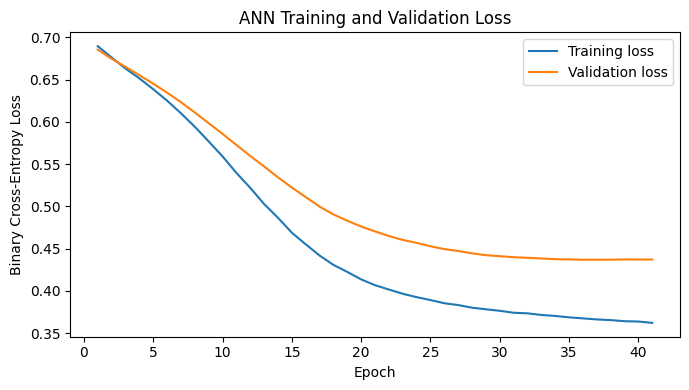

In [83]:
epochs = np.arange(1, actual_epochs + 1)
plt.figure(figsize=(7, 4))
plt.plot(epochs, history["train_loss"], label="Training loss")
plt.plot(epochs, history["val_loss"], label="Validation loss")
plt.title("ANN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.legend()
plt.tight_layout()
plt.savefig("ann_loss_curve.png", dpi=150)
plt.show()

loss_history = pd.DataFrame({
    "epoch": epochs,
    "train_loss": history["train_loss"],
    "val_loss": history["val_loss"]
})
loss_history.to_csv("ann_loss_history.csv", index=False)

In [84]:
X_test_t = torch.tensor(X_test.to_numpy(), dtype=torch.float32)

# D3 — Comparison and Evidence 
### Evaluate the restored ANN once on the same 60 test records using threshold 0.5. Report accuracy, precision, recall and F1, and compare F1 with logistic regression. Save ANN predictions and trained weights/model in models/. State a reasoned model preference; the ANN need not outperform logistic regression.


In [85]:
ann.eval()
with torch.no_grad():
    ann_prob = ann(X_test_t).numpy().ravel()
ann_pred = (ann_prob >= 0.5).astype(int)

ann_metrics = metric_row("ANN", y_test, ann_pred)
comparison = pd.concat([supervised_metrics, pd.DataFrame([ann_metrics])], ignore_index=True)
comparison.to_csv("model_comparison.csv", index=False)

ann_predictions = pd.DataFrame({
    "record_id": test_df["record_id"].to_numpy(),
    "true_label": y_test,
    "predicted_label": ann_pred,
    "class_1_probability": ann_prob
})
ann_predictions.to_csv("ann_test_predictions.csv", index=False)

comparison

,model,accuracy,precision,recall,f1
0,DummyClassifier,0.566667,0.566667,1.000000,0.723404
1,LogisticRegression,0.816667,0.828571,0.852941,0.840580
2,ANN,0.783333,0.800000,0.823529,0.811594


In [86]:
print("ANN vs Logistic Regression F1:")
print(comparison.loc[comparison.model.isin(["ANN", "LogisticRegression"]), ["model", "f1"]])
print("Model preference should be based on the observed test metrics, simplicity, and the small-holdout limitation. The ANN does not need to outperform Logistic Regression.")

# Reconciliation checks: identical test IDs and matching saved predictions.
assert np.array_equal(predictions.record_id.to_numpy(), ann_predictions.record_id.to_numpy())
assert np.array_equal(predictions.true_label.to_numpy(), ann_predictions.true_label.to_numpy())
print("Prediction reconciliation: PASS — both models use the same 60 test IDs.")

ANN vs Logistic Regression F1:
                model        f1
1  LogisticRegression  0.840580
2                 ANN  0.811594
Model preference should be based on the observed test metrics, simplicity, and the small-holdout limitation. The ANN does not need to outperform Logistic Regression.
Prediction reconciliation: PASS — both models use the same 60 test IDs.


# 7. Final saved evidence and quick checklist


In [92]:
required_files = [
    "splits.csv",
    "statistics_summary.csv",
    "inference_results.csv",
    "covariance_matrix.csv",
    "eigenvalues.csv",
    "supervised_metrics.csv",
    "logistic_test_predictions.csv",
    "k_selection_scores.csv",
    "cluster_profiles.csv",
    "ann_loss_history.csv",
    "model_comparison.csv",
    "ann_test_predictions.csv",
    "logistic_confusion_matrix.png",
    "ann_loss_curve.png",
    "quality_ann_state_dict.pt"
]

In [93]:
from pathlib import Path

check = pd.DataFrame({
    "file": [str(p) for p in required_files],
    "exists": [Path(p).exists() for p in required_files]
})

print(check.to_string(index=False))
print("All required notebook-generated evidence exists:", check["exists"].all())

                         file  exists
                   splits.csv    True
       statistics_summary.csv    True
        inference_results.csv    True
        covariance_matrix.csv    True
              eigenvalues.csv    True
       supervised_metrics.csv    True
logistic_test_predictions.csv    True
       k_selection_scores.csv    True
         cluster_profiles.csv    True
         ann_loss_history.csv    True
         model_comparison.csv    True
     ann_test_predictions.csv    True
logistic_confusion_matrix.png    True
           ann_loss_curve.png    True
    quality_ann_state_dict.pt    True
All required notebook-generated evidence exists: True
